# FHFA HOUSE PRICE PREDICTION INDEX

# Step1:Bussiness Problem
- THE U.S HOUSING MARKET IS INFLUENCED BY ECONOMIC CONDITIONS,INTEREST,RATES AND REGIONAL FACTORRS. PREDICTING FUTURE HOUSE PRICE TRENDS
- DOMAIN:Finance/Real Estate

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step2: Data Loading

In [2]:
df=pd.read_csv("C:\\Users\\Asus\\OneDrive\\Desktop\\power shheets\\Projects\\hpi_master.csv")
df

,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa
0,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,1,100.00,100.00
1,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,2,100.87,100.87
2,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,3,101.32,100.90
3,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,4,101.73,100.97
4,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,5,102.32,101.30
...,...,...,...,...,...,...,...,...,...,...
130692,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,1,201.68,204.83
130693,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,2,224.54,222.68
130694,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,3,233.53,226.83
130695,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2024,4,229.51,236.17


# Step3:Data Understanding
- yr,period:Time Identifires(Year and month)
- place_name:Region(state,metro,area,division)
- index_nsa:Non-seasonally adjjusted HPI(traget variable)
- index_sa:Seasonally adjusted HPI
- hpi_flavor:Type of index

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130697 entries, 0 to 130696
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   hpi_type    130697 non-null  object 
 1   hpi_flavor  130697 non-null  object 
 2   frequency   130697 non-null  object 
 3   level       130697 non-null  object 
 4   place_name  130697 non-null  object 
 5   place_id    130697 non-null  object 
 6   yr          130697 non-null  int64  
 7   period      130697 non-null  int64  
 8   index_nsa   130697 non-null  float64
 9   index_sa    43429 non-null   float64
dtypes: float64(2), int64(2), object(6)
memory usage: 10.0+ MB


In [4]:
df.describe()

,yr,period,index_nsa,index_sa
count,130697.000000,130697.000000,130697.000000,43429.000000
mean,2004.731471,2.619961,186.935563,210.954188
std,12.178554,1.440202,108.376306,105.327102
min,1975.000000,1.000000,18.680000,74.720000
25%,1995.000000,2.000000,110.710000,134.900000
50%,2005.000000,3.000000,164.060000,188.460000
75%,2015.000000,4.000000,225.790000,251.590000
max,2025.000000,12.000000,1268.370000,818.930000


# Step4:Data Exploration

In [5]:
df.isnull().sum()

hpi_type          0
hpi_flavor        0
frequency         0
level             0
place_name        0
place_id          0
yr                0
period            0
index_nsa         0
index_sa      87268
dtype: int64

In [6]:
df['index_sa'].isnull().sum()

np.int64(87268)

- 'index_sa' feature has 87268 missing values

In [7]:
df.duplicated().sum()

np.int64(0)

- There is no duplicated values

In [8]:
df['hpi_type'].unique()

array(['traditional', 'non-metro', 'manufactured', 'distress-free',
       'developmental'], dtype=object)

In [9]:
df['hpi_type'].value_counts()

hpi_type
traditional      122653
non-metro          5687
distress-free      1918
developmental       237
manufactured        202
Name: count, dtype: int64

In [10]:
df['hpi_flavor'].unique()

array(['purchase-only', 'all-transactions', 'expanded-data'], dtype=object)

In [11]:
df['hpi_flavor'].value_counts()

hpi_flavor
all-transactions    87167
purchase-only       28323
expanded-data       15207
Name: count, dtype: int64

In [12]:
df['frequency'].unique()

array(['monthly', 'quarterly'], dtype=object)

In [13]:
df['frequency'].value_counts()

frequency
quarterly    126567
monthly        4130
Name: count, dtype: int64

In [14]:
df['place_name'].unique()

array(['East North Central Division', 'East South Central Division',
       'Middle Atlantic Division', 'Mountain Division',
       'New England Division', 'Pacific Division',
       'South Atlantic Division', 'West North Central Division',
       'West South Central Division', 'United States', 'Abilene, TX',
       'Akron, OH', 'Albany, GA', 'Albany, OR',
       'Albany-Schenectady-Troy, NY', 'Albuquerque, NM', 'Alexandria, LA',
       'Allentown-Bethlehem-Easton, PA-NJ', 'Altoona, PA', 'Amarillo, TX',
       'Ames, IA', 'Amherst Town-Northampton, MA',
       'Anaheim-Santa Ana-Irvine, CA (MSAD)', 'Anchorage, AK',
       'Ann Arbor, MI', 'Anniston-Oxford, AL', 'Appleton, WI',
       'Arlington-Alexandria-Reston, VA-WV (MSAD)', 'Asheville, NC',
       'Athens-Clarke County, GA',
       'Atlanta-Sandy Springs-Roswell, GA (MSAD)',
       'Atlantic City-Hammonton, NJ', 'Auburn-Opelika, AL',
       'Augusta-Richmond County, GA-SC',
       'Austin-Round Rock-San Marcos, TX', 'Bakersfield-De

In [15]:
df['place_name'].value_counts()

place_name
United States                  1090
Middle Atlantic Division        888
East South Central Division     888
Mountain Division               888
East North Central Division     888
                               ... 
Gadsden, AL                     126
Johnstown, PA                   121
Beckley, WV                     113
Hinesville, GA                  103
Wildwood-The Villages, FL        98
Name: count, Length: 472, dtype: int64

In [16]:
df['level'].unique()

array(['USA or Census Division', 'MSA', 'State', 'Puerto Rico'],
      dtype=object)

In [17]:
df['level'].value_counts()

level
MSA                       91466
State                     29912
USA or Census Division     9082
Puerto Rico                 237
Name: count, dtype: int64

In [18]:
df['period'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

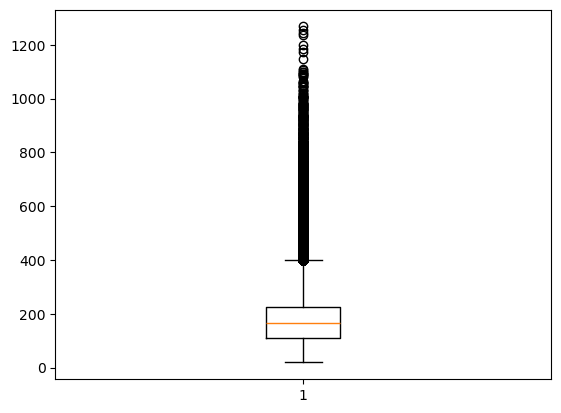

In [19]:
plt.boxplot(df['index_nsa']) 
plt.show()

In [20]:
df.columns

Index(['hpi_type', 'hpi_flavor', 'frequency', 'level', 'place_name',
       'place_id', 'yr', 'period', 'index_nsa', 'index_sa'],
      dtype='object')

In [21]:
descrete_categorical=['hpi_type', 'hpi_flavor', 'frequency', 'level', 'place_name','place_id']
Contineous=['index_nsa','index_sa']
descrete_count=['yr','period']

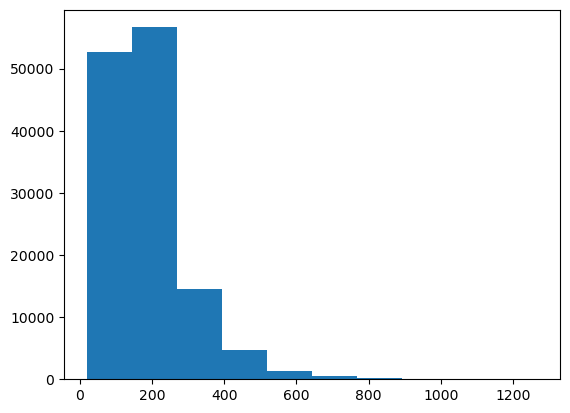

In [22]:
plt.hist(df['index_nsa'])
plt.show()

# Step5:Data Preprocessing

In [23]:
df['index_sa'].isnull().sum()/130696*100      

np.float64(66.7717451184428)

- 66% of the data is missing
- So now we drop the index_sa feature from the dataset

In [24]:
df=df.drop('index_sa',axis=1)
df.head()
df=df.drop('place_id',axis=1)
df.head()

,hpi_type,hpi_flavor,frequency,level,place_name,yr,period,index_nsa
0,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,1991,1,100.00
1,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,1991,2,100.87
2,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,1991,3,101.32
3,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,1991,4,101.73
4,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,1991,5,102.32


- 'place_id' feature not use for any analysis and prediction

In [25]:
df.isnull().sum()

hpi_type      0
hpi_flavor    0
frequency     0
level         0
place_name    0
yr            0
period        0
index_nsa     0
dtype: int64

- index_nsa has some outliers but retrain them

In [26]:
df['index_nsa'].skew()

np.float64(2.032355908328853)

-  2.03 Skewness is normal(skewness range is -3 to +3)

# Step6: Data Wrangling

- Feature Encoding

In [27]:
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df["hpi_type"]=oe.fit_transform(df[['hpi_type']])
df["hpi_flavor"]=oe.fit_transform(df[['hpi_flavor']])
df["frequency"]=oe.fit_transform(df[['frequency']])
df["level"]=oe.fit_transform(df[['level']])
df["place_name"]=oe.fit_transform(df[['place_name']])
df.head()

,hpi_type,hpi_flavor,frequency,level,place_name,yr,period,index_nsa
0,4.0,2.0,0.0,3.0,113.0,1991,1,100.00
1,4.0,2.0,0.0,3.0,113.0,1991,2,100.87
2,4.0,2.0,0.0,3.0,113.0,1991,3,101.32
3,4.0,2.0,0.0,3.0,113.0,1991,4,101.73
4,4.0,2.0,0.0,3.0,113.0,1991,5,102.32


- Now The Data is Encoded to Numeric

# X and y

In [28]:
X=df.drop('index_nsa',axis=1)
y=df['index_nsa']

# Train Test Split

In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

# Step7: Model Building

In [30]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

# Prediction

In [31]:
ytrain_predict=model.predict(X_train)
ytrain_predict

array([279.29304125, 117.20418442, 131.55682676, ..., 269.83893146,
        95.82899942,  89.5160023 ])

In [32]:
ytest_predict=model.predict(X_test)
ytest_predict

array([273.52501469, 199.30786348, 179.36618606, ..., 267.80871361,
       164.61164062, 100.39270056])

# Model Evaluation

# Cross validation score and RMSE

In [33]:
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import cross_val_score
print("RMSE for train data:",mean_squared_error(y_train,ytrain_predict))
print("R2 score for train data:",r2_score(y_train,ytrain_predict))
print("cross val score for train data:",cross_val_score(model,X_train,y_train,cv=5).mean())

RMSE for train data: 4973.692537793683
R2 score for train data: 0.5754104198304338
cross val score for train data: 0.5754119803312824


In [34]:
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import cross_val_score
print("RMSE for test data:",mean_squared_error(y_test,ytest_predict))
print("R2 score for test data:",r2_score(y_test,ytest_predict))
print("cross val score for test data:",cross_val_score(model,X_test,y_test,cv=5).mean())

RMSE for test data: 4957.930321351453
R2 score for test data: 0.5822931827859492
cross val score for test data: 0.5826227073624123


# Polynomial regression

In [38]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter=PolynomialFeatures(degree=6,include_bias=False)
polynomial_converter.fit_transform(X_train)

array([[4.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        6.53510560e+07, 6.46720000e+04, 6.40000000e+01],
       [4.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        1.01990810e+09, 2.04390400e+06, 4.09600000e+03],
       [4.00000000e+00, 2.00000000e+00, 1.00000000e+00, ...,
        3.99200400e+06, 1.99800000e+03, 1.00000000e+00],
       ...,
       [4.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        4.08040000e+06, 2.02000000e+03, 1.00000000e+00],
       [4.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        3.97204900e+06, 1.99300000e+03, 1.00000000e+00],
       [4.00000000e+00, 0.00000000e+00, 1.00000000e+00, ...,
        1.01480474e+09, 2.03878400e+06, 4.09600000e+03]])

In [39]:
import pandas as pd
X_train_poly=pd.DataFrame(polynomial_converter.fit_transform(X_train))

In [40]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train_poly,y_train)

LinearRegression()

In [41]:
print("Intercept:",model.intercept_)
print("coeficents:",model.coef_)

Intercept: 31096.849287652112
coeficents: [ 3.60389220e-18  3.27033191e-16 -1.19430799e-16 ...  1.20593558e-10
  1.74179649e-12  1.69167433e-14]


In [42]:
ypred_train=model.predict(X_train_poly)

In [43]:
from sklearn.metrics import r2_score
print("The r2 score of X_train",r2_score(y_train,ypred_train))
print("The cross val score:",cross_val_score(model,X_train_poly,y_train,cv=5).mean())

The r2 score of X_train 0.7382460261974497
The cross val score: 0.7379439705728196


In [44]:
X_test_poly=pd.DataFrame(polynomial_converter.transform(X_test))
ypred_test=model.predict(X_test_poly)

In [45]:
from sklearn.metrics import r2_score
print("The r2 score of X_test",r2_score(y_test,ypred_test))
print("The cross val score:",cross_val_score(model,X_test_poly,y_test,cv=5).mean())

The r2 score of X_test 0.7394543945239559
The cross val score: 0.7433402248652408


# Step8: predict future data

# Step8: Save the Model